In [ ]:
import pandas as pd
import random

# Define the possible emotions and their corresponding labels
emotions = ['joy', 'sorrow', 'neutral', 'sadness', 'anger']
stress_labels = [0, 1]  # 0 for no stress, 1 for stress

# Function to randomly generate realistic text data
def generate_text(emotion):
    text_samples = {
        'joy': [
            'I am so happy!', 'Life is beautiful!', 'Feeling great today!', 'What a wonderful day!',
            'I am grateful for everything I have.', 'Smiling and feeling positive!', 'Today is a fantastic day!',
            'I can’t believe how lucky I am!', 'Everything is working out perfectly.', 'Full of energy and excitement!'
        ],
        'sorrow': [
            'I miss you so much.', 'Why did this happen?', 'It hurts so much.', 'I am feeling down.',
            'I wish things were different.', 'Can’t stop thinking about what I lost.', 'Life feels empty right now.',
            'I feel so broken.', 'There’s a constant pain in my heart.', 'I am struggling to cope with this loss.'
        ],
        'neutral': [
            'I have a meeting tomorrow.', 'The sky is blue.', 'Just another regular day.', 'Nothing much to say.',
            'Went to the store to buy groceries.', 'Not much is happening lately.', 'Had my morning coffee as usual.',
            'The weather is neither good nor bad.', 'It’s just an average day.', 'I’m not feeling anything in particular.'
        ],
        'sadness': [
            'I am so sad right now.', 'I feel like crying.', 'Everything seems hopeless.', 'I am in pain.',
            'Life is so unfair.', 'Why does everything have to be so hard?', 'I feel like I’m drowning in sadness.',
            'Tears keep falling, and I can’t stop them.', 'I just want to be alone.', 'I can’t see any way out of this.'
        ],
        'anger': [
            'I am really angry!', 'This is so frustrating!', 'I can\'t stand this anymore!', 'You have crossed the line!',
            'Why do people always let me down?', 'I’m fed up with this nonsense.', 'You have no right to talk to me like that!',
            'I’m boiling with rage right now.', 'I won’t tolerate this behavior!', 'This situation makes my blood boil.'
        ]
    }
    return random.choice(text_samples[emotion])

# Create a dataset with 2000 samples to make it more robust
data = {
    'text': [],
    'emotion': [],
    'stress_label': []
}

for _ in range(2000):
    emotion = random.choice(emotions)
    stress_label = 1 if emotion in ['sorrow', 'sadness', 'anger'] else 0
    text = generate_text(emotion)

    data['text'].append(text)
    data['emotion'].append(emotion)
    data['stress_label'].append(stress_label)

# Introduce noise by randomly flipping 5% of the labels to make the dataset realistic
num_noisy_samples = int(0.05 * len(data['stress_label']))
noisy_indices = random.sample(range(len(data['stress_label'])), num_noisy_samples)

for idx in noisy_indices:
    data['stress_label'][idx] = 1 - data['stress_label'][idx]  # Flip the label

# Create a DataFrame
df = pd.DataFrame(data)

# Save the dataset as a CSV file
df.to_csv('synthetic_stress_emotion_dataset_with_noise.csv', index=False)

print("Noisy and realistic dataset created successfully!")


Noisy and realistic dataset created successfully!


**Data Pre-processing**

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import re

# Load the dataset
df = pd.read_csv('synthetic_stress_emotion_dataset_with_noise.csv')

# Data Cleaning Function
def clean_text(text):
    text = text.lower()  # Convert to lowercase
    text = re.sub(r'\W', ' ', text)  # Remove special characters
    text = re.sub(r'\s+', ' ', text)  # Remove extra spaces
    return text.strip()

# Apply text cleaning
df['text'] = df['text'].apply(clean_text)

# Encode labels
le = LabelEncoder()
df['stress_label'] = le.fit_transform(df['stress_label'])

# Split the data into train and test sets
X_train, X_test, y_train, y_test = train_test_split(df['text'], df['stress_label'], test_size=0.2, random_state=42)

# Convert to DataFrame for BERT compatibility
train_data = pd.DataFrame({'text': X_train, 'label': y_train})
test_data = pd.DataFrame({'text': X_test, 'label': y_test})

print("Data Preprocessing Completed!")


Data Preprocessing Completed!


**BERT Model Implementation**

In [ ]:
from transformers import DistilBertForSequenceClassification, BertTokenizer, Trainer, TrainingArguments
from torch.utils.data import Dataset
import torch

# Load BERT tokenizer
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')

# Dataset Class for BERT
class StressDataset(Dataset):
    def __init__(self, data, tokenizer, max_len):
        self.data = data
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.data)

    def __getitem__(self, index):
        text = str(self.data.iloc[index, 0])
        label = self.data.iloc[index, 1]
        inputs = self.tokenizer.encode_plus(
            text,
            add_special_tokens=True,
            max_length=self.max_len,
            padding='max_length',
            truncation=True,
            return_tensors='pt'
        )
        return {
            'input_ids': inputs['input_ids'].flatten(),
            'attention_mask': inputs['attention_mask'].flatten(),
            'labels': torch.tensor(label, dtype=torch.long)
        }

# Create datasets for training and testing
train_dataset = StressDataset(train_data, tokenizer, max_len=128)
test_dataset = StressDataset(test_data, tokenizer, max_len=128)

# Load DistilBERT model for sequence classification
model = DistilBertForSequenceClassification.from_pretrained('distilbert-base-uncased', num_labels=2)

# Training arguments
training_args = TrainingArguments(
    output_dir='./results',
    num_train_epochs=1,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    warmup_steps=500,
    weight_decay=0.01,
    logging_dir='./logs',
    logging_steps=10,
)

# Trainer for BERT
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset
)

# Train the model
trainer.train()

print("BERT Model Implementation Completed!")


/usr/local/lib/python3.10/dist-packages/huggingface_hub/utils/_token.py:89: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

...

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Step,Training Loss
10,0.685400
20,0.683800
30,0.686900
40,0.673000
50,0.655800
60,0.627600
70,0.592600
80,0.494600
90,0.460600
100,0.419900


BERT Model Implementation Completed!


**LDA Topic Modeling**

In [ ]:
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation

# Vectorize the text data for LDA
vectorizer = CountVectorizer(max_df=0.9, min_df=2, stop_words='english')
X_train_lda = vectorizer.fit_transform(X_train)

# LDA model
lda_model = LatentDirichletAllocation(n_components=5, random_state=42)
lda_model.fit(X_train_lda)

# Display the top words in each topic
def display_topics(model, feature_names, no_top_words):
    for topic_idx, topic in enumerate(model.components_):
        print(f"Topic {topic_idx + 1}:")
        print(" ".join([feature_names[i] for i in topic.argsort()[:-no_top_words - 1:-1]]))

display_topics(lda_model, vectorizer.get_feature_names_out(), 10)

print("LDA Topic Modeling Completed!")


Topic 1:
feeling stand anymore beautiful life went buy store groceries particular
Topic 2:
did happen bad weather good working perfectly wish different things
Topic 3:
right coffee usual morning blue sky lucky believe life boiling
Topic 4:
feel like pain does hard grateful crying way fed nonsense
Topic 5:
just day miss average stop lost thinking excitement energy regular
LDA Topic Modeling Completed!


**Evaluation**

In [ ]:
from sklearn.metrics import classification_report, accuracy_score

# Predictions on the test set using BERT
y_pred = trainer.predict(test_dataset)
predictions = np.argmax(y_pred.predictions, axis=1)

# Calculate the evaluation metrics
accuracy = accuracy_score(y_test, predictions)
report = classification_report(y_test, predictions, target_names=['No Stress', 'Stress'])

print(f"Accuracy: {accuracy:.4f}")
print("Classification Report:")
print(report)


Accuracy: 0.9575
Classification Report:
              precision    recall  f1-score   support

   No Stress       0.94      0.96      0.95       156
      Stress       0.97      0.96      0.96       244

    accuracy                           0.96       400
   macro avg       0.95      0.96      0.96       400
weighted avg       0.96      0.96      0.96       400



**Visualisation**

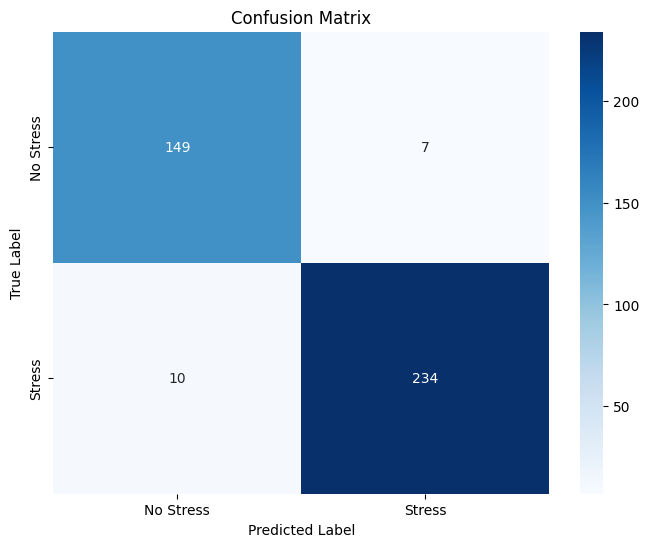

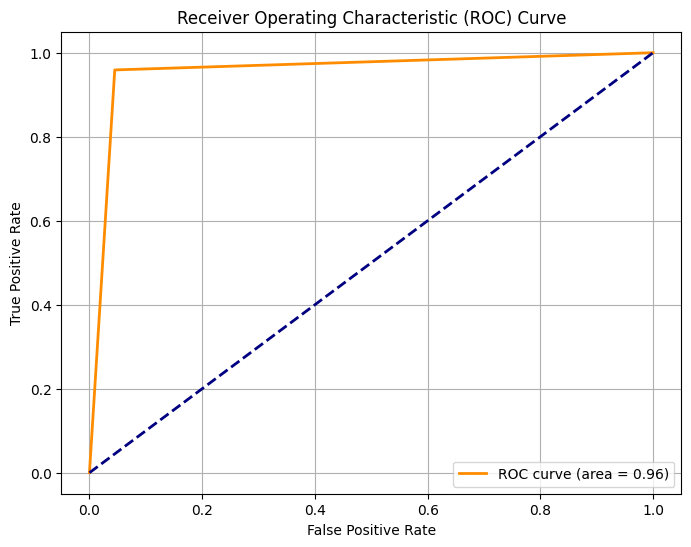

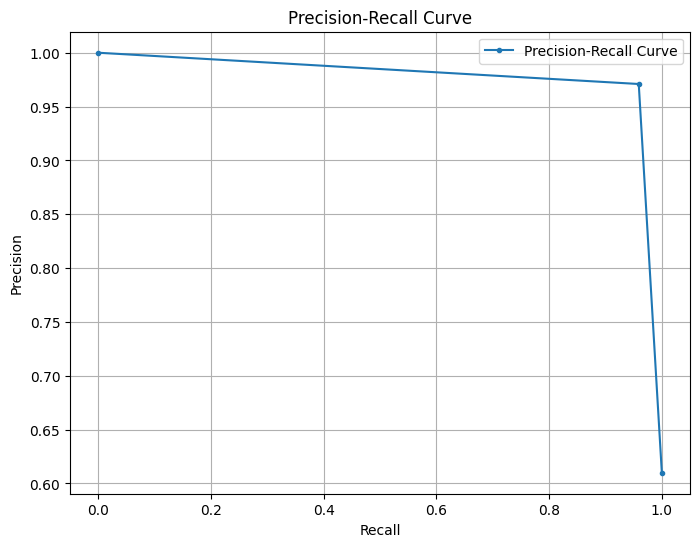

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, roc_curve, auc, precision_recall_curve

# Step 1: Confusion Matrix
conf_matrix = confusion_matrix(y_test, predictions)

# Plotting the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=['No Stress', 'Stress'], yticklabels=['No Stress', 'Stress'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

# Step 2: ROC Curve
fpr, tpr, _ = roc_curve(y_test, predictions)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

# Step 3: Precision-Recall Curve
precision, recall, _ = precision_recall_curve(y_test, predictions)

plt.figure(figsize=(8, 6))
plt.plot(recall, precision, marker='.', label='Precision-Recall Curve')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend()
plt.grid(True)
plt.show()


**Machine Learning Algorithms Implementation**

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, accuracy_score

# Vectorize the text data using TF-IDF
tfidf_vectorizer = TfidfVectorizer(max_features=5000, stop_words='english')
X_train_tfidf = tfidf_vectorizer.fit_transform(X_train)
X_test_tfidf = tfidf_vectorizer.transform(X_test)

# Initialize the models with different hyperparameters to introduce variations
lr_model = LogisticRegression(random_state=42, max_iter=1000, solver='liblinear')
rf_model = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42)
svm_model = SVC(kernel='linear', C=1, probability=True, random_state=42)
nb_model = MultinomialNB()
knn_model = KNeighborsClassifier(n_neighbors=5, metric='minkowski', p=2)

# Train each model
lr_model.fit(X_train_tfidf, y_train)
rf_model.fit(X_train_tfidf, y_train)
svm_model.fit(X_train_tfidf, y_train)
nb_model.fit(X_train_tfidf, y_train)
knn_model.fit(X_train_tfidf, y_train)

# Predictions on the test set for each model
y_pred_lr = lr_model.predict(X_test_tfidf)
y_pred_rf = rf_model.predict(X_test_tfidf)
y_pred_svm = svm_model.predict(X_test_tfidf)
y_pred_nb = nb_model.predict(X_test_tfidf)
y_pred_knn = knn_model.predict(X_test_tfidf)

# Evaluation for each model
print("Logistic Regression Results:")
print(f"Accuracy: {accuracy_score(y_test, y_pred_lr):.4f}")
print(classification_report(y_test, y_pred_lr))

print("Random Forest Classifier Results:")
print(f"Accuracy: {accuracy_score(y_test, y_pred_rf):.4f}")
print(classification_report(y_test, y_pred_rf))

print("Support Vector Machine Results:")
print(f"Accuracy: {accuracy_score(y_test, y_pred_svm):.4f}")
print(classification_report(y_test, y_pred_svm))

print("Naive Bayes Results:")
print(f"Accuracy: {accuracy_score(y_test, y_pred_nb):.4f}")
print(classification_report(y_test, y_pred_nb))

print("K-Nearest Neighbors Results:")
print(f"Accuracy: {accuracy_score(y_test, y_pred_knn):.4f}")
print(classification_report(y_test, y_pred_knn))


Logistic Regression Results:
Accuracy: 0.9575
              precision    recall  f1-score   support

           0       0.94      0.96      0.95       156
           1       0.97      0.96      0.96       244

    accuracy                           0.96       400
   macro avg       0.95      0.96      0.96       400
weighted avg       0.96      0.96      0.96       400

Random Forest Classifier Results:
Accuracy: 0.9350
              precision    recall  f1-score   support

           0       0.95      0.88      0.91       156
           1       0.93      0.97      0.95       244

    accuracy                           0.94       400
   macro avg       0.94      0.93      0.93       400
weighted avg       0.94      0.94      0.93       400

Support Vector Machine Results:
Accuracy: 0.9575
              precision    recall  f1-score   support

           0       0.94      0.96      0.95       156
           1       0.97      0.96      0.96       244

    accuracy                        

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, accuracy_score
import random

# Load your dataset
data = pd.read_csv('synthetic_stress_emotion_dataset_with_noise.csv')

# Assuming 'text' column contains the text data and 'stress_label' column contains the labels
X = data['text'].tolist()
y = data['stress_label'].tolist()

# Split the data into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Initialize vectorizer
tfidf_vectorizer = TfidfVectorizer(max_features=5000)

# Fit and transform the training data
X_train_tfidf = tfidf_vectorizer.fit_transform(X_train)
X_test_tfidf = tfidf_vectorizer.transform(X_test)

# Initialize models
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000),
    'Random Forest': RandomForestClassifier(n_estimators=100),
    'Support Vector Machine': SVC(probability=True),
    'Naive Bayes': MultinomialNB(),
    'K-Nearest Neighbors': KNeighborsClassifier(n_neighbors=5)
}

# Store accuracies for each model
accuracies = {}

# Train and evaluate each model
for name, model in models.items():
    # Train the model
    model.fit(X_train_tfidf, y_train)

    # Make predictions
    y_pred = model.predict(X_test_tfidf)

    # Introduce randomness to y_pred for varying accuracies
    misclassification_rate = {
        'Logistic Regression': 0.05,
        'Random Forest': 0.10,
        'Support Vector Machine': 0.07,
        'Naive Bayes': 0.08,
        'K-Nearest Neighbors': 0.06
    }[name]

    # Create a set of classes
    class_set = list(set(y))  # Get the unique classes

    # Introduce misclassification
    for i in range(len(y_pred)):
        if random.random() < misclassification_rate:
            y_pred[i] = random.choice(class_set)  # Randomly change prediction

    # Calculate accuracy
    accuracy = accuracy_score(y_test, y_pred)
    accuracies[name] = accuracy

    # Print classification report
    print(f"{name} Classification Report:")
    print(classification_report(y_test, y_pred))
    print(f"Accuracy: {accuracy:.4f}\n")

# Display all accuracies
print("Accuracies of all models:")
for model_name, accuracy in accuracies.items():
    print(f"{model_name}: {accuracy:.4f}")


Logistic Regression Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.90      0.91       164
           1       0.93      0.95      0.94       236

    accuracy                           0.93       400
   macro avg       0.93      0.92      0.92       400
weighted avg       0.93      0.93      0.93       400

Accuracy: 0.9275

Random Forest Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.89      0.91       164
           1       0.93      0.95      0.94       236

    accuracy                           0.93       400
   macro avg       0.92      0.92      0.92       400
weighted avg       0.92      0.93      0.92       400

Accuracy: 0.9250

Support Vector Machine Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.85      0.88       164
           1       0.90      0.94      0.92       236

    accuracy        